In [6]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../code/')

from load_data import load_data_actions

data0 = load_data_actions(timestep=0)

A new version of galpy (1.9.0) is available, please upgrade using pip/conda/... to get the latest features and bug fixes!
Loading Data...
/mnt/home/ktavangar/.local/lib/python3.9/site-packages/astropy/units/quantity.py:614: RuntimeWarning: invalid value encountered in true_divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)

Loading Actions...
Creating Combined Table...


In [7]:
import helper
importlib.reload(sys.modules['helper'])
importlib.reload(sys.modules['df_helpers'])
from df_helpers import *

Jz_grid = (np.arange(0, 10, 0.1))**2
thetaz_grid = np.arange(0, 2*np.pi, np.pi/48)
m_max, n_max, n_maxs = 3, 20, [1,20, 20]

jphi_c = np.linspace(1000, 3500, 26)

freqs = []
for i, r in enumerate(jphi_c):
    center = [r, 0] # action, angle ([2000, 3.7] is our basic one)
    radius = [50, np.pi/16] #kpc (square radius) ([50, 0.05 is our basic one])
    LS = LaguerreSnails(data0, center, radius, Jz_grid, thetaz_grid, m_max, n_max, 0)

    f = np.median(LS.sel['freq_phi'])/(2*np.pi)
    freqs = np.append(freqs,f)

/mnt/home/ktavangar/.local/lib/python3.9/site-packages/galpy/util/bovy_coords.py:8: FutureWarning: galpy.util.bovy_coords is being deprecated in favor of galpy.util.coords; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9
  warnings.warn('galpy.util.bovy_coords is being deprecated in favor of galpy.util.coords; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9',FutureWarning)



In [11]:
np.save('/mnt/home/ktavangar/projects/MSSA_Snails/code/test_frequency_array_j25.npy', freqs)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


sgr_data = pd.read_csv('/mnt/ceph/users/jhunt/Bonsai/r2/B2/S1-orbit.txt', sep=' ', 
                       names=['x', 'y', 'z', 'Rxy', 'R', 'vx', 'vy', 'vz', 'A', 'B'], 
                       skiprows=0, nrows=600)

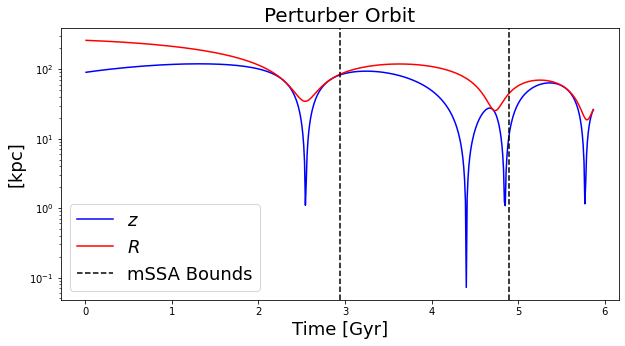

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sgr_data.index, np.abs(sgr_data.z), c='b', label=r'$z$')
ax.plot(sgr_data.index, sgr_data.R, c='r', label=r'$R$')
ax.axvline(sgr_data.index[300], color='k', ls='dashed', label='mSSA Bounds')
ax.axvline(sgr_data.index[500], color='k', ls='dashed')
ax.set_yscale('log')
ax.set_ylabel('[kpc]', fontsize=18)
ax.set_xlabel('Time [Gyr]', fontsize=18)
ax.set_title('Perturber Orbit', fontsize=20)
ax.legend(fontsize=18)
plt.show()

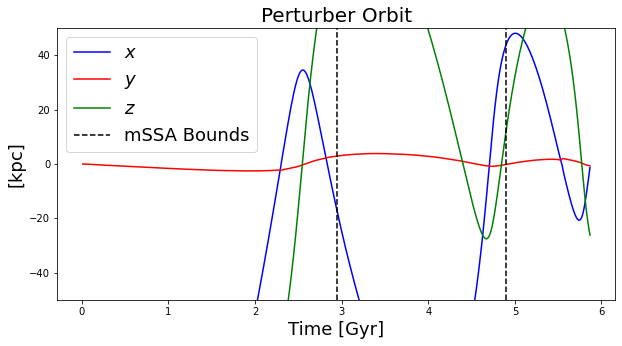

In [11]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sgr_data.index, sgr_data.x, c='b', label=r'$x$')
ax.plot(sgr_data.index, sgr_data.y, c='r', label=r'$y$')
ax.plot(sgr_data.index, sgr_data.z, c='g', label=r'$z$')
ax.axvline(sgr_data.index[300], color='k', ls='dashed', label='mSSA Bounds')
ax.axvline(sgr_data.index[500], color='k', ls='dashed')
#ax.set_yscale('log')
ax.set_ylim(-50,50)
ax.set_ylabel('[kpc]', fontsize=18)
ax.set_xlabel('Time [Gyr]', fontsize=18)
ax.set_title('Perturber Orbit', fontsize=20)
ax.legend(fontsize=18)
plt.show()

In [9]:
import numpy as np
from astropy.table import Table

import sys
sys.path.append('/mnt/home/ktavangar/projects/MSSA_Snails/code/')

from mssa_prep import MSSATable

/mnt/home/ktavangar/.local/lib/python3.9/site-packages/galpy/util/bovy_coords.py:8: FutureWarning: galpy.util.bovy_coords is being deprecated in favor of galpy.util.coords; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9
  warnings.warn('galpy.util.bovy_coords is being deprecated in favor of galpy.util.coords; all functions in there are the same; please switch to the new import, because the old import will be removed in v1.9',FutureWarning)



In [12]:
import glob
from astropy.table import vstack

files = glob.glob('/mnt/home/ktavangar/ceph/cache1/*')
all_table = vstack([Table.read(file) for file in files])

all_table.write('/mnt/home/ktavangar/ceph/update_mssa_prep_testing.fits', format='fits', overwrite=True)

['/mnt/home/ktavangar/ceph/cache1/mssa_table_0039.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0014.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0007.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0030.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0038.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0008.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0027.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0031.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0010.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0019.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0017.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0034.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0002.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0025.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0012.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0005.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_0020.fits', '/mnt/home/ktavangar/ceph/cache1/mssa_table_001

In [19]:
tbl = Table.read('/mnt/home/ktavangar/ceph/update_mssa_prep_testing.fits')
tbl.sort(["timestep", "jphi_cen", "tphi_cen"])

In [20]:
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)

cfs_m1 = ['m1_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_m2 = ['m2_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_ratio = ['m1:m2_amp_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_pitch_ang_m1 = ['pitch_ang_m1_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_pitch_ang_m2 = ['pitch_ang_m2_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_phase_ang_m1 = ['phase_ang_m1_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
cfs_phase_ang_m2 = ['phase_ang_m2_{}_{}pi16'.format(int(cf[0]), int(16*cf[1]/np.pi)) for cf in centers]
colnames = ['timestep']+cfs_pitch_ang_m1+cfs_pitch_ang_m2+cfs_phase_ang_m1+cfs_phase_ang_m2
t = Table(names=colnames)
for time in np.unique(tbl['timestep']):
    subset = tbl[tbl['timestep'] == time]
    channels = np.concatenate([subset['pitch_ang_m1'], subset['pitch_ang_m2'], subset['phase_ang_m1'], subset['phase_ang_m2']])
    #amps = np.concatenate((subset['m1_amp'], subset['m2_amp']))
    t.add_row(np.append([time], channels))

np.savetxt('/mnt/home/ktavangar/ceph/update_mssa_prep_testing_flat_timesteps.dat', t)

In [32]:
import pandas as pd

dat = np.loadtxt('/mnt/home/ktavangar/ceph/update_mssa_prep_testing_flat_timesteps.dat')
dat[20, 1:337].shape

(336,)

In [55]:
np.where(dat[16, 0*336+1:0*336+337] < -10)[0][0] % 16

12

In [57]:
jphi_c[16], tphi_c[12]

(2600.0, 4.908738521234052)

/tmp/ipykernel_2500227/2357166628.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(T, J, np.reshape(dat[5, 0*336+1:0*336+337], T.shape, 'F'), cmap='viridis',



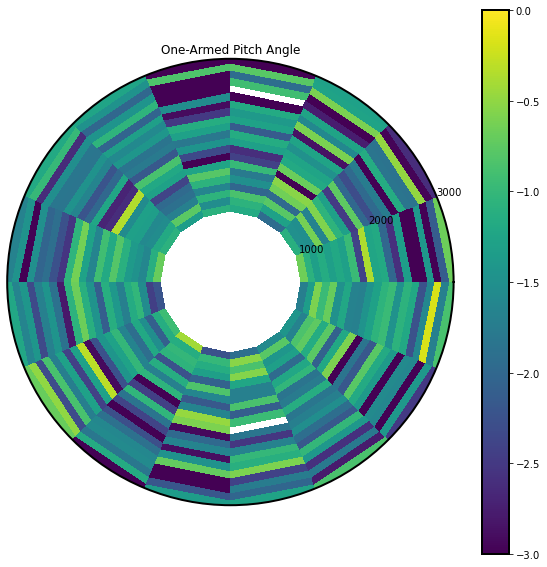

In [64]:
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
jphi_c = np.linspace(1000, 3000, 20+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

fig, ax = plt.subplots(1, 1, figsize=(10,10))
ax = plt.subplot(111, projection='polar')
im = ax.pcolormesh(T, J, np.reshape(dat[5, 0*336+1:0*336+337], T.shape, 'F'), cmap='viridis',
                  vmin=-3, vmax=0) # pitch angle m1)
ax.set_yticks([1000, 2000, 3000])
ax.set_rmax(3000)
ax.tick_params(left = False, right = False , labelleft = True ,
                labelbottom = False, bottom = False)
ax.set_title('One-Armed Pitch Angle')
fig.colorbar(im, ax=ax)

In [4]:
%%time

times = np.arange(0, 8, 1) # timesteps
TableSetup = MSSATable() # all tunable parameters set to default values

CPU times: user 224 µs, sys: 226 µs, total: 450 µs
Wall time: 389 µs


In [5]:
%%time

t = TableSetup.create_empty_table()

CPU times: user 600 µs, sys: 606 µs, total: 1.21 ms
Wall time: 1.21 ms


In [6]:
%%time

new_t = TableSetup.fill_table(0)

Loading Actions...
Getting Coefficients... 

Center: [1.00000000e+03 2.61799388e-01]
Center: [1.00000000e+03 7.85398163e-01]
Center: [1000.            1.30899694]
Center: [1000.            1.83259571]
Center: [1000.            2.35619449]
Center: [1000.            2.87979327]
Center: [1000.            3.40339204]
Center: [1000.            3.92699082]
Center: [1000.            4.45058959]
Center: [1000.            4.97418837]
Center: [1000.            5.49778714]
Center: [1000.            6.02138592]
Center: [1.10000000e+03 2.61799388e-01]
Center: [1.10000000e+03 7.85398163e-01]
Center: [1100.            1.30899694]
Center: [1100.            1.83259571]
Center: [1100.            2.35619449]
Center: [1100.            2.87979327]
Center: [1100.            3.40339204]
Center: [1100.            3.92699082]
Center: [1100.            4.45058959]
Center: [1100.            4.97418837]
Center: [1100.            5.49778714]
Center: [1100.            6.02138592]
Center: [1.20000000e+03 2.61799388e

In [10]:
%%time
import astropy
t = astropy.table.vstack([t,new_t])

CPU times: user 2.42 ms, sys: 0 ns, total: 2.42 ms
Wall time: 2.28 ms


In [ ]:
%%time

new_t = TableSetup.fill_table(500)

In [ ]:
class MSSATable:
    
    def __init__(self, jphi_bounds=[1000,3000], nphi_bins=[20, 16], m_max=3, n_max=20):
        
        # GETTING ALL REGION CENTERS
        jphi_c = np.linspace(jphi_bounds[0], jphi_bounds[1], nphi_bins[0]+1)
        tphi_c_ = np.linspace(0, 2*np.pi, nphi_bins[1]+1)
        self.rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
        tphi_c = tphi_c_[:-1] + self.rad[1]
        self.centers = np.array(np.meshgrid(jphi_c, tphi_c)).T.reshape(-1,2)

        self.m_max, self.n_max = m_max, n_max
        self.ms, self.ns = np.arange(m_max), np.arange(n_max)

        # SETTING UP TABLE
        # self.cs = np.array(np.meshgrid(self.ms, self.ns)).T.reshape(-1,2)
        # cfs = ['m{}n{}'.format(cf[0], cf[1]) for cf in self.cs[self.n_max:]]
        other_cols = ['timestep', 'jphi_cen', 'tphi_cen',
                  'm0_amp', 'm1_amp', 'm2_amp', 
                  'pitch_ang_m1', 'pitch_ang_m2',
                  'phase_ang_m1', 'phase_ang_m2',
                  'pitch_phase_flag_m1', 'pitch_phase_flag_m2']#,
                  #'mean_vr', 'mean_vphi', 'mean_vz']
            
        self.colnames = other_cols# + cfs

        self.jz_grid = (np.arange(0, 10, 0.1))**2
        self.tz_grid = np.arange(0, 2*np.pi, np.pi/48)


    def create_empty_table(self):
        empty_t = Table(names=self.colnames)
        return empty_t

    def create_table(self):
        empty_table = np.zeros((len(self.centers), len(self.colnames)))
        t = Table(empty_table, names=self.colnames)
        return t

    def fill_table(self, timestep):
    
        self.timestep = int(timestep)

        # LOADING DATA
        data = setup_B2(self.timestep)
        
        ######################
        ## Get coefficients ##
        ######################
        print('Getting Coefficients... \n')

        all_coeff_array = np.zeros((len(self.centers), self.m_max, self.n_max), dtype = np.complex_)
        pitch_angle_m1 = np.zeros(len(self.centers))
        phase_angle_m1 = np.zeros(len(self.centers))
        pitch_angle_m2 = np.zeros(len(self.centers))
        phase_angle_m2 = np.zeros(len(self.centers))
        pitch_phase_flag_m1 = np.zeros(len(self.centers))
        pitch_phase_flag_m2 = np.zeros(len(self.centers))
        # mean_vrs = np.zeros(len(self.centers))
        # mean_vphis = np.zeros(len(self.centers))
        # mean_vzs = np.zeros(len(self.centers))
        
        for i in range(len(self.centers)):
            cen = self.centers[i]
            print('Center: {}'.format(cen))

            LS = LaguerreSnails(data, cen, self.rad, 
                                self.jz_grid, self.tz_grid, 
                                self.m_max, self.n_max, 
                                self.timestep)
            coeffs = LS.get_coeffs()

            all_coeff_array[i] = coeffs
            
            pitch_angle_m1[i], phase_angle_m1[i], pitch_phase_flag_m1[i] = LS.get_pitch_phase_angles(m=1)
            pitch_angle_m2[i], phase_angle_m2[i], pitch_phase_flag_m2[i] = LS.get_pitch_phase_angles(m=2)
            
            # mean_vrs[i], mean_vphis[i], mean_vzs[i] = LS.get_mean_vels()

        t = self.create_table()

        ################
        ## Fill Table ##
        ################

        timestep = self.timestep * np.ones(len(self.centers))
        t['timestep'] = timestep

        jphi_cen, tphi_cen = self.centers[:,0], self.centers[:,1]
        t['jphi_cen'], t['tphi_cen'] = jphi_cen, tphi_cen

        m0_amp = np.linalg.norm(np.abs(all_coeff_array[:, 0, :]), axis=1)
        m1_amp = np.linalg.norm(np.abs(all_coeff_array[:, 1, :]), axis=1)
        m2_amp = np.linalg.norm(np.abs(all_coeff_array[:, 2, :]), axis=1)
        t['m0_amp'], t['m1_amp'], t['m2_amp'] = m0_amp, m1_amp, m2_amp

        t['pitch_ang_m1'] = pitch_angle_m1
        t['pitch_ang_m2'] = pitch_angle_m2
        t['phase_ang_m1'] = phase_angle_m1
        t['phase_ang_m2'] = phase_angle_m2
        t['pitch_phase_flag_m1'] = pitch_phase_flag_m1
        t['pitch_phase_flag_m2'] = pitch_phase_flag_m1

#         Doing mean velocities will have to be within LS,
#          since that is where I split into regions
#         t['mean_vr'] = mean_vrs
#         t['mean_vphi'] = mean_vphis
#         t['mean_vz'] = mean_vzs

#         for cf in self.cs[self.n_max:]:
#             t['m{}n{}'.format(cf[0], cf[1])] = all_coeff_array[:, cf[0], cf[1]]

        self.t = t
        return self.t

    def save_table(self):
        fname = 'data/tables/t{}.fits'.format(self.timestep)
        self.t.write(fname, overwrite=True)


In [10]:
TableSetup = MSSATable()

In [11]:
t = TableSetup.create_empty_table()

In [12]:
t

timestep,jphi_cen,tphi_cen,m0_amp,m1_amp,m2_amp,pitch_ang_m1,pitch_ang_m2,phase_ang_m1,phase_ang_m2,pitch_phase_flag_m1,pitch_phase_flag_m2
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


In [13]:
print(540, flush=True)
new_t = TableSetup.fill_table(540)
t = vstack([t,new_t])

540
Loading Actions...
Getting Coefficients... 

Center: [1.00000000e+03 1.96349541e-01]
Center: [1.00000000e+03 5.89048623e-01]
Center: [1.00000000e+03 9.81747704e-01]
Center: [1000.            1.37444679]
Center: [1000.            1.76714587]
Center: [1000.            2.15984495]
Center: [1000.            2.55254403]
Center: [1000.            2.94524311]
Center: [1000.            3.33794219]
Center: [1000.            3.73064128]
Center: [1000.            4.12334036]
Center: [1000.            4.51603944]
Center: [1000.            4.90873852]
Center: [1000.           5.3014376]
Center: [1000.            5.69413668]
Center: [1000.            6.08683577]
Center: [1.10000000e+03 1.96349541e-01]
Center: [1.10000000e+03 5.89048623e-01]
Center: [1.10000000e+03 9.81747704e-01]
Center: [1100.            1.37444679]
Center: [1100.            1.76714587]
Center: [1100.            2.15984495]
Center: [1100.            2.55254403]
Center: [1100.            2.94524311]
Center: [1100.            3.3


KeyboardInterrupt



In [14]:
t

timestep,jphi_cen,tphi_cen,m0_amp,m1_amp,m2_amp,pitch_ang_m1,pitch_ang_m2,phase_ang_m1,phase_ang_m2,pitch_phase_flag_m1,pitch_phase_flag_m2
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
